# Notebook 08 — Baseline Machine Learning Models

## Objective

This notebook trains the first baseline machine learning models for customer churn prediction.

The objective is to compare simple and interpretable algorithms before evaluating more advanced ensemble methods.

The models are trained on the leakage-free analytical dataset prepared in Notebook 07.

In [31]:
from pathlib import Path

import joblib
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    ConfusionMatrixDisplay
)


In [32]:
PROJECT_ROOT = Path.cwd().parent

DATA_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "dataset_modelisation.parquet"
)

MODEL_DIR = (
    PROJECT_ROOT
    / "models"
)

pipeline_data = joblib.load(
    MODEL_DIR / "preprocessing_pipeline.joblib"
)

preprocessor = pipeline_data["pipeline"]

In [33]:
df = pd.read_parquet(DATA_FILE)

TARGET = "CHURN"

X = df.drop(
    columns=[
        "CUSTOMER_NO",
        TARGET,
        "JOURS_DEPUIS_REVUE"
    ]
)

y = df[TARGET]

In [34]:
from sklearn.model_selection import train_test_split

X_train,\
X_test,\
y_train,\
y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [35]:
logistic_model = Pipeline(

    steps=[

        (
            "preprocessing",
            preprocessor
        ),

        (
            "classifier",
            LogisticRegression(

            solver="liblinear",

            max_iter=3000,

            class_weight="balanced",

            random_state=42

            )
        )

    ]

)

In [36]:
logistic_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['AGE','TRANCHE_AGE','ANCIENNETE_CLIENT_ANNEES',...,'REVUE_EN_RETARD', 'A_HISTORIQUE_REVUE','NB_COMPTES']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By spec

In [37]:
y_pred = logistic_model.predict(
    X_test
)

y_prob = logistic_model.predict_proba(
    X_test
)[:,1]

In [38]:
results = {

    "Accuracy":
        accuracy_score(
            y_test,
            y_pred
        ),

    "Precision":
        precision_score(
            y_test,
            y_pred,
            average="binary",
            zero_division=0
        ),

    "Recall":
        recall_score(
            y_test,
            y_pred,
            average="binary",
            zero_division=0
        ),

    "F1":
        f1_score(
            y_test,
            y_pred,
            average="binary",
            zero_division=0
        ),

    "ROC_AUC":
        roc_auc_score(
            y_test,
            y_prob
        )

}

pd.DataFrame(
    results,
    index=["Logistic Regression"]
)
results_df = pd.DataFrame(
    results,
    index=["Logistic Regression"]
)

display(results_df)

results_df.to_excel(
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "baseline_logistic_results.xlsx"
)

,Accuracy,Precision,Recall,F1,ROC_AUC
Logistic Regression,0.663387,0.081461,0.508531,0.140427,0.616592


# LOGISTIC REGRESSION — PR-AUC

In [39]:
# ==========================================================
# LOGISTIC REGRESSION — PR-AUC
# ==========================================================

logistic_pr_auc = average_precision_score(
    y_test,
    y_prob
)

results["PR_AUC"] = logistic_pr_auc

results_df = pd.DataFrame(
    results,
    index=["Logistic Regression"]
)

display(results_df)

results_df.to_excel(
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "baseline_logistic_results.xlsx"
)

print(
    f"Logistic Regression PR-AUC : "
    f"{logistic_pr_auc:.4f}"
)

,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Logistic Regression,0.663387,0.081461,0.508531,0.140427,0.616592,0.084653


Logistic Regression PR-AUC : 0.0847


In [40]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[24815 12099]
 [ 1037  1073]]


In [41]:
cm_df = pd.DataFrame(
    cm,
    index=["Actual Non-Churn", "Actual Churn"],
    columns=["Predicted Non-Churn", "Predicted Churn"]
)

display(cm_df)

cm_df.to_excel(
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "baseline_logistic_confusion_matrix.xlsx"
)

,Predicted Non-Churn,Predicted Churn
Actual Non-Churn,24815,12099
Actual Churn,1037,1073


In [42]:
print(

classification_report(

y_test,

y_pred

)

)

              precision    recall  f1-score   support

           0       0.96      0.67      0.79     36914
           1       0.08      0.51      0.14      2110

    accuracy                           0.66     39024
   macro avg       0.52      0.59      0.47     39024
weighted avg       0.91      0.66      0.76     39024



## Business Interpretation — Logistic Regression

Logistic Regression provides the first baseline model for customer churn prediction.

Although the model assumes a linear relationship between the predictors and the target, it offers high interpretability and serves as a reference point for more complex algorithms.

Because the dataset is imbalanced, recall and F1-score are considered more informative than accuracy alone.

The performance of this model will be compared with Decision Tree and Random Forest in the following sections.

## Business Interpretation — Logistic Regression

Logistic Regression was selected as the first baseline model because it is simple, interpretable and widely used in binary classification problems.

The model correctly identifies approximately 52% of customers who actually churn. This level of recall is acceptable for an initial baseline model, although the precision remains low because many non-churn customers are predicted as potential churners.

The use of class balancing intentionally favours the detection of churners rather than maximizing overall accuracy. In a banking retention context, identifying more customers at risk of leaving is generally preferable to missing valuable churn cases, even if this generates additional false positive alerts.

This baseline establishes a reference point against which more advanced algorithms such as Decision Tree and Random Forest will be compared.

# Decision Tree Classifier

The Decision Tree model is trained to capture non-linear relationships between customer characteristics and churn.

In [43]:
from sklearn.tree import DecisionTreeClassifier

In [44]:
decision_tree = Pipeline(

    steps=[

        (
            "preprocessing",
            preprocessor
        ),

        (
            "classifier",

            DecisionTreeClassifier(

                max_depth=8,

                min_samples_leaf=20,

                random_state=42

            )

        )

    ]

)

In [45]:
decision_tree.fit(

    X_train,

    y_train

)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['AGE','TRANCHE_AGE','ANCIENNETE_CLIENT_ANNEES',...,'REVUE_EN_RETARD', 'A_HISTORIQUE_REVUE','NB_COMPTES']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By spec

In [46]:
dt_pred = decision_tree.predict(

    X_test

)

dt_prob = decision_tree.predict_proba(

    X_test

)[:,1]

In [47]:
dt_results = {

    "Accuracy":

    accuracy_score(

        y_test,

        dt_pred

    ),

    "Precision":

    precision_score(

        y_test,

        dt_pred,

        zero_division=0

    ),

    "Recall":

    recall_score(

        y_test,

        dt_pred,

        zero_division=0

    ),

    "F1":

    f1_score(

        y_test,

        dt_pred,

        zero_division=0

    ),

    "ROC_AUC":

    roc_auc_score(

        y_test,

        dt_prob

    )

}

dt_results_df = pd.DataFrame(

    dt_results,

    index=["Decision Tree"]

)

display(dt_results_df)

,Accuracy,Precision,Recall,F1,ROC_AUC
Decision Tree,0.948058,0.726776,0.063033,0.116005,0.666105


# DECISION TREE — PR-AUC


In [48]:
# ==========================================================
# DECISION TREE — PR-AUC
# ==========================================================

dt_pr_auc = average_precision_score(
    y_test,
    dt_prob
)

dt_results["PR_AUC"] = dt_pr_auc

dt_results_df = pd.DataFrame(
    dt_results,
    index=["Decision Tree"]
)

display(dt_results_df)

print(
    f"Decision Tree PR-AUC : "
    f"{dt_pr_auc:.4f}"
)

,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Decision Tree,0.948058,0.726776,0.063033,0.116005,0.666105,0.17716


Decision Tree PR-AUC : 0.1772


In [49]:
dt_cm = confusion_matrix(

    y_test,

    dt_pred

)

display(

pd.DataFrame(

dt_cm,

index=["Actual Non Churn","Actual Churn"],

columns=["Pred Non Churn","Pred Churn"]

)

)

,Pred Non Churn,Pred Churn
Actual Non Churn,36864,50
Actual Churn,1977,133


In [50]:
print(

classification_report(

y_test,

dt_pred

)

)

              precision    recall  f1-score   support

           0       0.95      1.00      0.97     36914
           1       0.73      0.06      0.12      2110

    accuracy                           0.95     39024
   macro avg       0.84      0.53      0.54     39024
weighted avg       0.94      0.95      0.93     39024



## Business Interpretation — Decision Tree

Decision Tree captures non-linear customer behaviours and interaction effects that cannot be identified by Logistic Regression.

Its performance will be compared with Logistic Regression to evaluate whether non-linear decision rules improve churn detection.

Section 2 — Random Forest

In [51]:
from sklearn.ensemble import RandomForestClassifier

In [52]:
random_forest = Pipeline(

    steps=[

        (

            "preprocessing",

            preprocessor

        ),

        (

            "classifier",

            RandomForestClassifier(

                n_estimators=300,

                max_depth=12,

                min_samples_leaf=10,

                class_weight="balanced",

                random_state=42,

                n_jobs=-1

            )

        )

    ]

)

In [53]:
random_forest.fit(

X_train,

y_train

)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['AGE','TRANCHE_AGE','ANCIENNETE_CLIENT_ANNEES',...,'REVUE_EN_RETARD', 'A_HISTORIQUE_REVUE','NB_COMPTES']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By spec

In [54]:
rf_pred = random_forest.predict(

X_test

)

rf_prob = random_forest.predict_proba(

X_test

)[:,1]

In [55]:
rf_results={

"Accuracy":

accuracy_score(

y_test,

rf_pred

),

"Precision":

precision_score(

y_test,

rf_pred,

zero_division=0

),

"Recall":

recall_score(

y_test,

rf_pred,

zero_division=0

),

"F1":

f1_score(

y_test,

rf_pred,

zero_division=0

),

"ROC_AUC":

roc_auc_score(

y_test,

rf_prob

)

}

rf_results_df=pd.DataFrame(

rf_results,

index=["Random Forest"]

)

display(

rf_results_df

)

,Accuracy,Precision,Recall,F1,ROC_AUC
Random Forest,0.785286,0.121117,0.474882,0.193008,0.705129


In [56]:
# ==========================================================
# RANDOM FOREST — PR-AUC
# ==========================================================

rf_pr_auc = average_precision_score(
    y_test,
    rf_prob
)

rf_results["PR_AUC"] = rf_pr_auc

rf_results_df = pd.DataFrame(
    rf_results,
    index=["Random Forest"]
)

display(rf_results_df)

print(
    f"Random Forest PR-AUC : "
    f"{rf_pr_auc:.4f}"
)

,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Random Forest,0.785286,0.121117,0.474882,0.193008,0.705129,0.186987


Random Forest PR-AUC : 0.1870


In [57]:
rf_cm=confusion_matrix(

y_test,

rf_pred

)

display(

pd.DataFrame(

rf_cm,

index=["Actual Non Churn","Actual Churn"],

columns=["Pred Non Churn","Pred Churn"]

)

)

,Pred Non Churn,Pred Churn
Actual Non Churn,29643,7271
Actual Churn,1108,1002


In [58]:
print(

classification_report(

y_test,

rf_pred

)

)

              precision    recall  f1-score   support

           0       0.96      0.80      0.88     36914
           1       0.12      0.47      0.19      2110

    accuracy                           0.79     39024
   macro avg       0.54      0.64      0.53     39024
weighted avg       0.92      0.79      0.84     39024



## Business Interpretation — Random Forest

Random Forest combines multiple decision trees to improve prediction stability and reduce overfitting.

The ensemble approach generally provides better predictive performance while preserving robustness on heterogeneous banking datasets.

 ROC CURVES — BASELINE MODELS

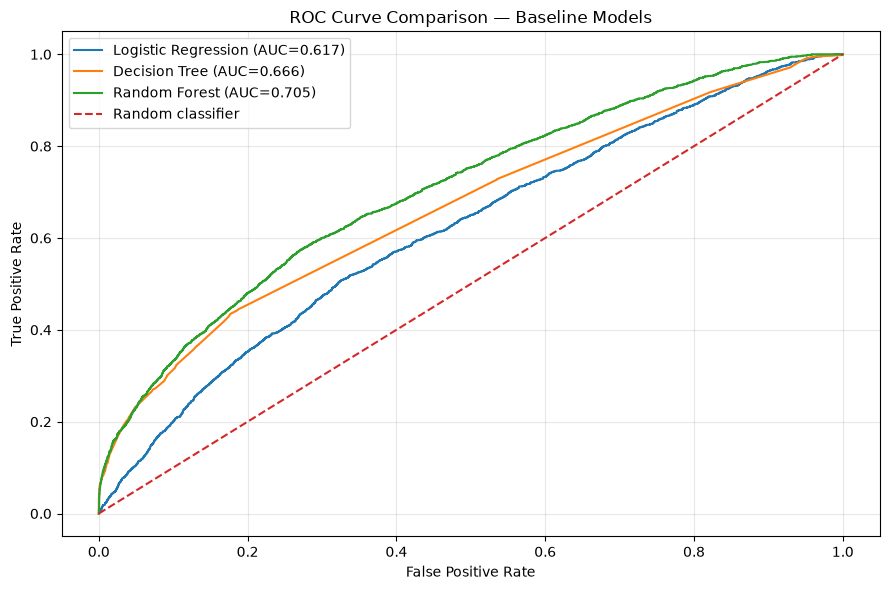

In [59]:
# ==========================================================
# ROC CURVES — BASELINE MODELS
# ==========================================================

fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    y_prob
)

fpr_dt, tpr_dt, _ = roc_curve(
    y_test,
    dt_prob
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    rf_prob
)

plt.figure(figsize=(9, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC={results['ROC_AUC']:.3f})"
)

plt.plot(
    fpr_dt,
    tpr_dt,
    label=f"Decision Tree (AUC={dt_results['ROC_AUC']:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC={rf_results['ROC_AUC']:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison — Baseline Models")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "baseline_roc_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Precision–Recall comparison

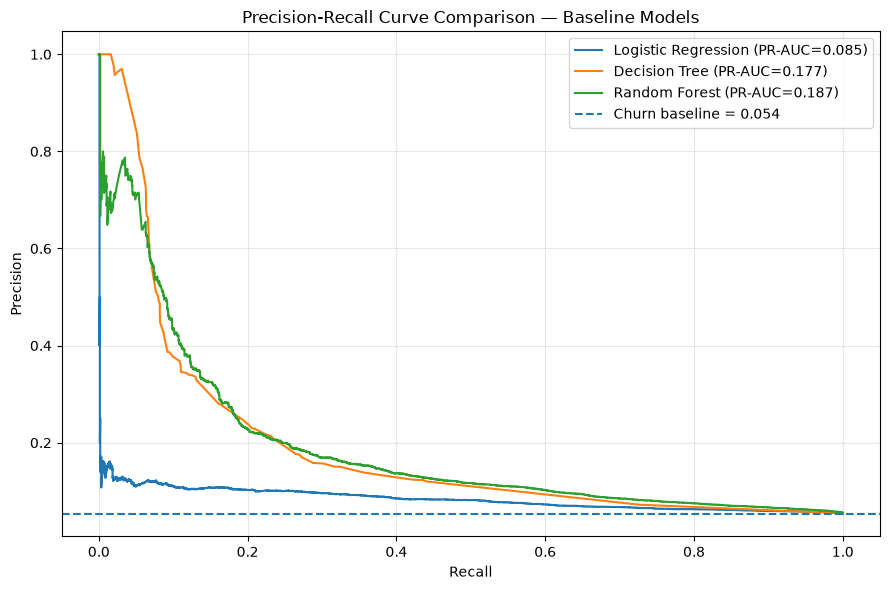

In [60]:
# ==========================================================
# PRECISION-RECALL CURVES — BASELINE MODELS
# ==========================================================

precision_lr, recall_lr, _ = precision_recall_curve(
    y_test,
    y_prob
)

precision_dt, recall_dt, _ = precision_recall_curve(
    y_test,
    dt_prob
)

precision_rf, recall_rf, _ = precision_recall_curve(
    y_test,
    rf_prob
)

plt.figure(figsize=(9, 6))

plt.plot(
    recall_lr,
    precision_lr,
    label=f"Logistic Regression (PR-AUC={logistic_pr_auc:.3f})"
)

plt.plot(
    recall_dt,
    precision_dt,
    label=f"Decision Tree (PR-AUC={dt_pr_auc:.3f})"
)

plt.plot(
    recall_rf,
    precision_rf,
    label=f"Random Forest (PR-AUC={rf_pr_auc:.3f})"
)

plt.axhline(
    y=y_test.mean(),
    linestyle="--",
    label=f"Churn baseline = {y_test.mean():.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(
    "Precision-Recall Curve Comparison — Baseline Models"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "baseline_precision_recall_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

 CONFUSION MATRICES — BASELINE MODELS

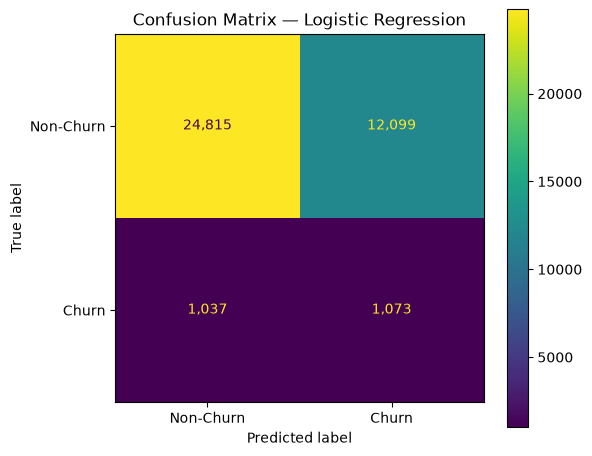

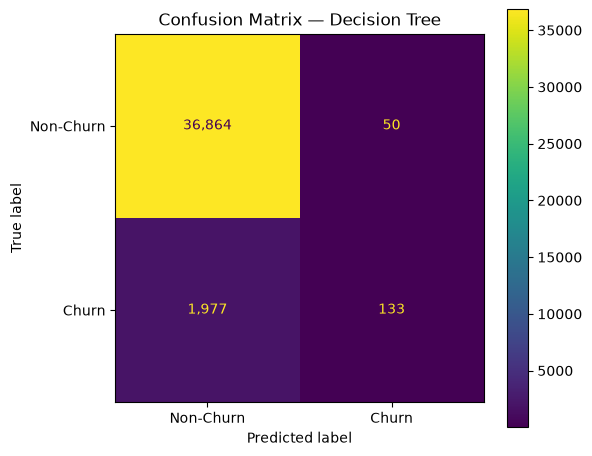

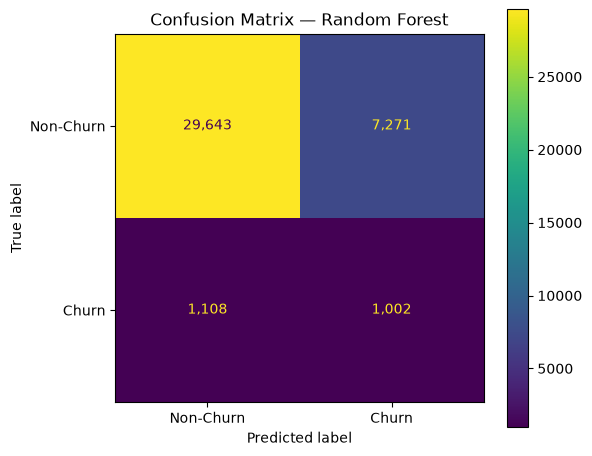

In [61]:
# ==========================================================
# CONFUSION MATRICES — BASELINE MODELS
# ==========================================================

models_predictions = {
    "Logistic Regression": y_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
}

for model_name, prediction in models_predictions.items():

    fig, ax = plt.subplots(figsize=(6, 5))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        prediction,
        display_labels=[
            "Non-Churn",
            "Churn"
        ],
        values_format=",d",
        ax=ax
    )

    ax.set_title(
        f"Confusion Matrix — {model_name}"
    )

    plt.tight_layout()

    safe_name = (
        model_name
        .lower()
        .replace(" ", "_")
    )

    plt.savefig(
        PROJECT_ROOT
        / "outputs"
        / "figures"
        / f"confusion_matrix_{safe_name}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

Section 3 — Final Comparison

In [62]:
# ==========================================================
# FINAL BASELINE MODEL COMPARISON
# ==========================================================

comparison = pd.concat(
    [
        results_df,
        dt_results_df,
        rf_results_df
    ]
)

comparison = comparison[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "PR_AUC"
    ]
].round(4)

display(comparison)

comparison.to_excel(
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "baseline_models_comparison.xlsx"
)

print(
    "Official baseline comparison exported successfully."
)

,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Logistic Regression,0.6634,0.0815,0.5085,0.1404,0.6166,0.0847
Decision Tree,0.9481,0.7268,0.0630,0.1160,0.6661,0.1772
Random Forest,0.7853,0.1211,0.4749,0.1930,0.7051,0.1870


Official baseline comparison exported successfully.


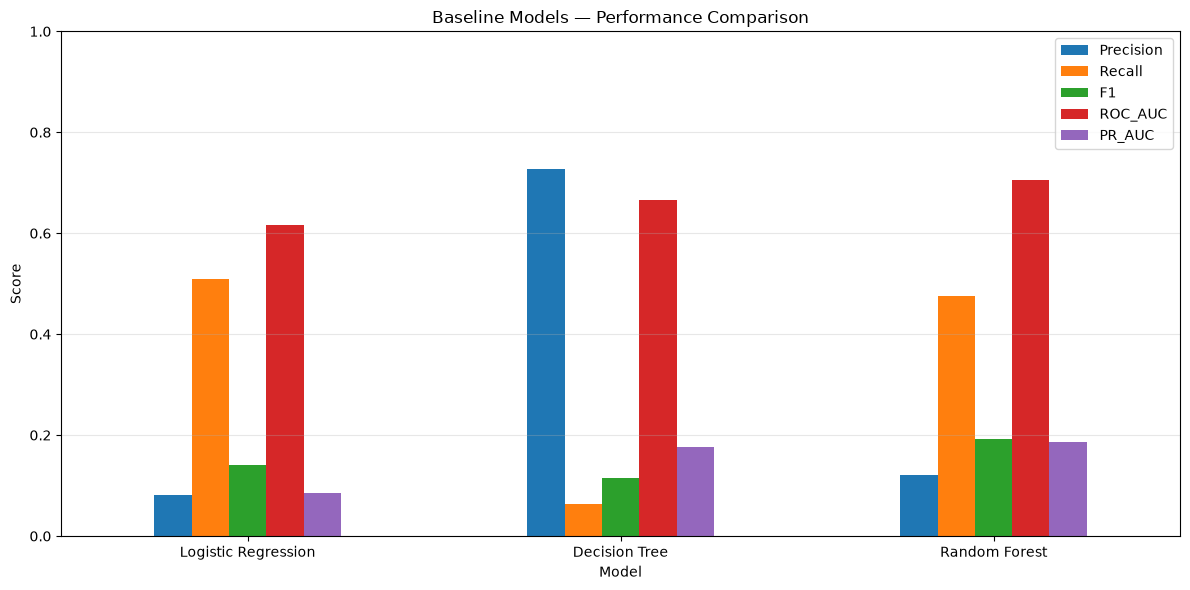

In [63]:
# ==========================================================
# BASELINE MODEL PERFORMANCE COMPARISON
# ==========================================================

metrics_for_comparison = [
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC",
    "PR_AUC"
]

comparison[
    metrics_for_comparison
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Baseline Models — Performance Comparison"
)

plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "baseline_model_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

 PRECISION VS RECALL TRADE-OFF

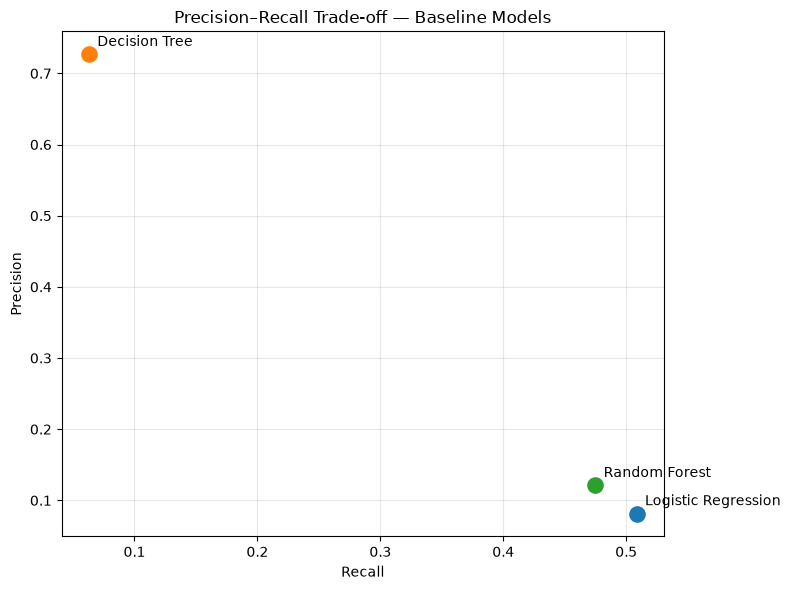

In [64]:
# ==========================================================
# PRECISION VS RECALL TRADE-OFF
# ==========================================================

plt.figure(figsize=(8, 6))

for model_name in comparison.index:

    x = comparison.loc[
        model_name,
        "Recall"
    ]

    y_value = comparison.loc[
        model_name,
        "Precision"
    ]

    plt.scatter(
        x,
        y_value,
        s=120
    )

    plt.annotate(
        model_name,
        (
            x,
            y_value
        ),
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(
    "Precision–Recall Trade-off — Baseline Models"
)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "baseline_precision_recall_tradeoff.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Executive Conclusion

Three baseline machine learning models were evaluated for customer churn prediction.

Logistic Regression provides the most interpretable baseline.

Decision Tree introduces non-linear decision rules.

Random Forest improves robustness by combining multiple trees and generally achieves the strongest predictive performance among the baseline models.

The selected baseline model will serve as the benchmark before evaluating more advanced ensemble algorithms.

In [65]:
import joblib

best_model = random_forest

joblib.dump(
    best_model,
    MODEL_DIR / "best_baseline_model.joblib"
)

print("Best baseline model saved successfully.")

Best baseline model saved successfully.


Interpretation logique:

Logistic Regression détecte environ la moitié des churners, ama beaucoup de faux positifs.
Decision Tree precision très haute, ama il rate presque tous les churners: Recall = 6.3%. Donc son Accuracy de 94.8% est trompeuse.
Random Forest est clairement le meilleur baseline global: meilleur F1, ROC-AUC et PR-AUC, avec Recall encore correct.

Les confusion matrices confirment exactement ça:

Logistic: 1073 TP, ama 12099 FP.
Decision Tree: seulement 133 TP, donc trop conservateur.
Random Forest: 1002 TP avec moins de FP que Logistic.

Et les deux courbes aussi sont bonnes:

ROC: Random Forest domine globalement.
Precision-Recall: Random Forest ≈ Decision Tree au début, mais RF garde un meilleur compromis global.
PR-AUC baseline aléatoire ≈ 0.054, donc les trois modèles font mieux que le hasard, surtout RF.